1. **Cargar datos procesados** desde `artifacts/datos_procesados.pkl`.
2. **Entrenar modelos base** (LogisticRegression, RandomForest, XGBoost).
3. **Evaluar con métricas** (accuracy, precision, recall, f1, roc\_auc).
4. **Guardar modelos** y **métricas**.
5. **Visualizar resultados**:

   * Tabla comparativa.
   * Gráficas ROC.
   * Importancia de variables (RandomForest / XGBoost).

In [15]:
# --- Configuración inicial ---
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)

# --- Rutas ---
ARTIFACTS_DIR = "../artifacts"
DATA_DIR = "../data/processed"
MODELOS_DIR = os.path.join(ARTIFACTS_DIR, "modelos")
RESULTADOS_PATH = os.path.join(ARTIFACTS_DIR, "resultados_modelos.csv")
DATOS_PROCESADOS_PATH = os.path.join(DATA_DIR, "datos_procesados.pkl")

os.makedirs(MODELOS_DIR, exist_ok=True)

### 🔹 Cargar datos procesados


In [8]:
with open(DATOS_PROCESADOS_PATH, "rb") as f:
    X_train, X_test, y_train, y_test = pickle.load(f)

print("Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)


Shapes:
X_train: (5634, 10963) X_test: (1409, 10963)
y_train: (5634,) y_test: (1409,)


### 🔹 Definir modelos

In [9]:
modelos = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="logloss", random_state=42)
}

### 🔹 Entrenamiento y evaluación

In [ ]:


# Codificar las etiquetas
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

print("Clases originales:", le.classes_)  # ['Canceló' 'Retenido']

resultados = []
fprs, tprs = {}, {}

for nombre, modelo in modelos.items():
    print(f"Entrenando modelo: {nombre}...")
    modelo.fit(X_train, y_train_enc)  # usar codificado

    y_pred_enc = modelo.predict(X_test)
    y_pred = le.inverse_transform(y_pred_enc)  # volver a texto para métricas

    y_prob = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, "predict_proba") else None

    metrics = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, pos_label="Canceló"),
        "recall": recall_score(y_test, y_pred, pos_label="Canceló"),
        "f1": f1_score(y_test, y_pred, pos_label="Canceló"),
        "roc_auc": roc_auc_score((y_test == "Canceló").astype(int), y_prob) if y_prob is not None else None
    }
    resultados.append(metrics)

    # Guardar modelo entrenado
    modelo_path = os.path.join(MODELOS_DIR, f"{nombre}.pkl")
    with open(modelo_path, "wb") as f:
        pickle.dump(modelo, f)

    # Guardar curvas ROC
    if y_prob is not None:
        fpr, tpr, _ = roc_curve((y_test == "Canceló").astype(int), y_prob)
        fprs[nombre], tprs[nombre] = fpr, tpr

df_resultados = pd.DataFrame(resultados)
df_resultados.to_csv(RESULTADOS_PATH, index=False)
df_resultados


Clases originales: ['Canceló' 'Retenido']
Entrenando modelo: LogisticRegression...
Entrenando modelo: RandomForest...
Entrenando modelo: XGBoost...


/home/david/Predicci-n-de-Cancelaci-n-Churn-/venv_churn/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [17:59:21] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,modelo,accuracy,precision,recall,f1,roc_auc
0,LogisticRegression,0.810504,0.661631,0.585561,0.621277,0.145659
1,RandomForest,0.794890,0.655678,0.478610,0.553323,0.163653
2,XGBoost,0.776437,0.579515,0.574866,0.577181,0.184226


### 🔹 Curvas ROC

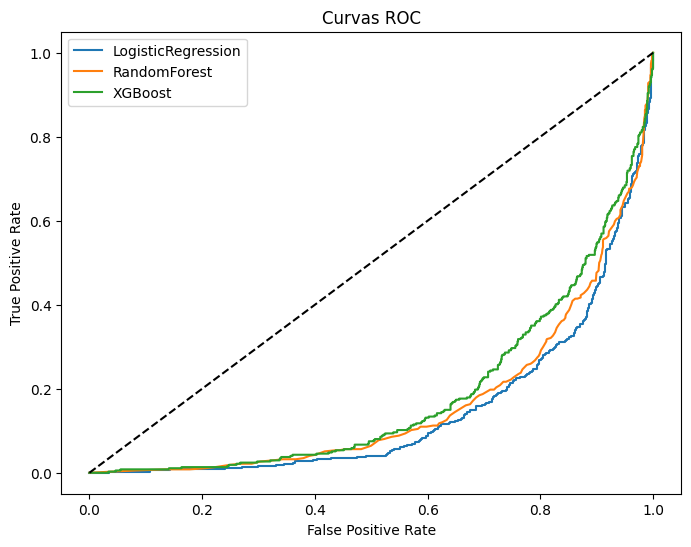

In [12]:
plt.figure(figsize=(8,6))
for nombre in fprs:
    plt.plot(fprs[nombre], tprs[nombre], label=nombre)
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC")
plt.legend()
plt.show()

### 🔹 Importancia de variables (RandomForest / XGBoost)

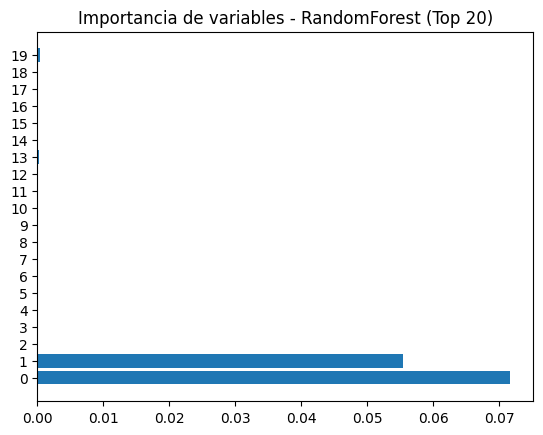

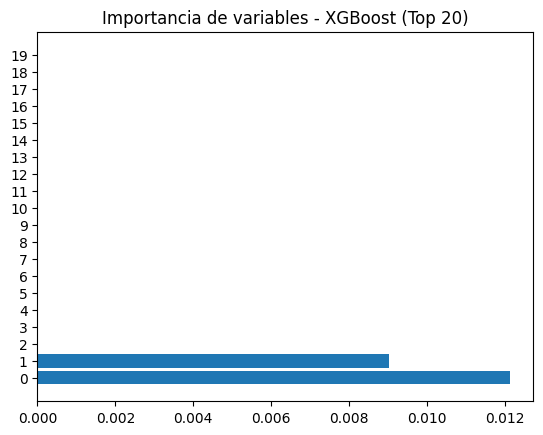

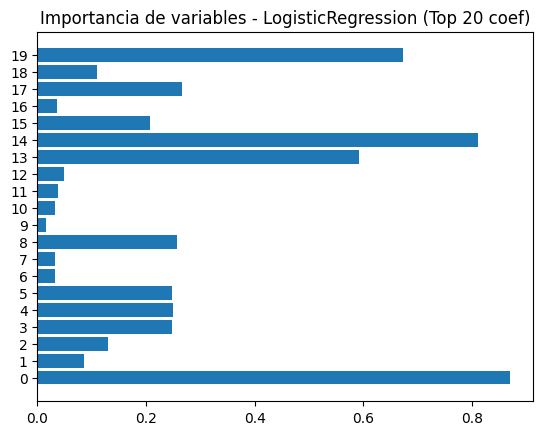

In [16]:
# RandomForest
if "RandomForest" in modelos:
    rf = modelos["RandomForest"]
    importancias = rf.feature_importances_[:20]
    plt.barh(range(len(importancias)), importancias)
    plt.yticks(range(len(importancias)), range(len(importancias)))
    plt.title("Importancia de variables - RandomForest (Top 20)")
    plt.show()

# XGBoost
if "XGBoost" in modelos:
    xgb = modelos["XGBoost"]
    importancias = xgb.feature_importances_[:20]
    plt.barh(range(len(importancias)), importancias)
    plt.yticks(range(len(importancias)), range(len(importancias)))
    plt.title("Importancia de variables - XGBoost (Top 20)")
    plt.show()

# LogisticRegression
if "LogisticRegression" in modelos:
    lr = modelos["LogisticRegression"]
    coef = lr.coef_[0]
    importancias = np.abs(coef)[:20]
    plt.barh(range(len(importancias)), importancias)
    plt.yticks(range(len(importancias)), range(len(importancias)))
    plt.title("Importancia de variables - LogisticRegression (Top 20 coef)")
    plt.show()
